<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB17 · Subir por la pendiente: aprender con el gradiente

**Parte 2 · Matemáticas y herramientas para robots — Lección 6**

> En el **NB16** aprendiste a medir la **pendiente**: hacia dónde sube el terreno y cuánto. Y viste que, en la montaña del palo
> de escoba, la pendiente **señala la cumbre** sin necesidad de ver la montaña.

Hoy convertimos eso en **aprendizaje**. La idea cabe en una frase:

> **Mide la pendiente, da un pasito cuesta arriba, y repite.**

Se llama **ascenso por la pendiente** (o por el **gradiente**, la palabra que aprenderás hoy). Cuando en vez de subir una montaña
se quiere bajar a un valle (por ejemplo, para hacer un error lo más pequeño posible), se llama **descenso por gradiente**, y es,
sin exagerar, **el algoritmo más importante de la inteligencia artificial**: con él se entrenan las redes neuronales que reconocen
caras, traducen idiomas, conducen coches... y mueven humanoides.

Hoy lo construirás tú, en unas pocas líneas, y lo usarás para que el palo de escoba ajuste **sus dos ruedecillas a la vez**,
subiendo por un mapa de la montaña que dibujaremos. Y aprenderás sus dos trampas: la **tasa de aprendizaje** y los **óptimos
locales**.


## 1 · La receta, en una colina de juguete

Empecemos con una montaña de juguete, de la que conocemos la respuesta: una colina cuya cumbre está en **x = 3**, con altura 10.
Su función es h(x) = 10 − (x − 3)² (una parábola puesta boca abajo, NB16). Y traemos la función `pendiente` del NB16:


In [1]:
def colina(x):
    return 10 - (x - 3) ** 2

def pendiente(funcion, x, h):
    return (funcion(x + h) - funcion(x - h)) / (2 * h)

print("Altura en x = 0:", colina(0), "| en x = 3:", colina(3))
print("Pendiente en x = 0:", round(pendiente(colina, 0, 0.001), 3))

Altura en x = 0: 1 | en x = 3: 10
Pendiente en x = 0: 6.0


En x = 0 estamos abajo (altura 1), y la pendiente es **+6**: el terreno sube hacia la derecha. La cumbre (altura 10) está en 3.

Ahora, **la receta del ascenso**. Estamos en x. Medimos la pendiente. Y nos movemos **en la dirección que dice la pendiente, una
cantidad proporcional a ella**:

```
   x nuevo  =  x  +  tasa × pendiente
```

- Si la pendiente es **positiva** (sube a la derecha), x **aumenta**: vamos a la derecha. ✓
- Si es **negativa** (sube a la izquierda), x **disminuye**: vamos a la izquierda. ✓
- Si es **cero** (cumbre), x **no cambia**: nos quedamos. ✓

El número **tasa** es un número pequeño que decide **lo largos que son los pasos**. Se llama **tasa de aprendizaje** (en inglés,
*learning rate*). Probemos con tasa = 0,1, empezando en x = 0, diez pasos:


In [2]:
x = 0.0
tasa = 0.1
for paso in range(1, 11):
    x = x + tasa * pendiente(colina, x, 0.001)
    print("paso", paso, "| x =", round(x, 3), "| altura =", round(colina(x), 3))

paso 1 | x = 0.6 | altura = 4.24
paso 2 | x = 1.08 | altura = 6.314
paso 3 | x = 1.464 | altura = 7.641
paso 4 | x = 1.771 | altura = 8.49
paso 5 | x = 2.017 | altura = 9.034
paso 6 | x = 2.214 | altura = 9.382
paso 7 | x = 2.371 | altura = 9.604
paso 8 | x = 2.497 | altura = 9.747
paso 9 | x = 2.597 | altura = 9.838
paso 10 | x = 2.678 | altura = 9.896


**El ordenador sube la colina solo.** x va 0,6 → 1,08 → 1,46 → ... → 2,68, acercándose a 3, y la altura sube hacia 10. Nadie le ha
dicho dónde está la cumbre: solo ha seguido la pendiente.

Fíjate en un detalle precioso: los pasos son **largos al principio** (0,6) y **cada vez más cortos** (el último, menos de 0,1). ¿Por
qué? Porque el paso es **proporcional a la pendiente**, y la pendiente se va haciendo pequeña al acercarse a la cumbre (NB16: "si es
pequeña, estás cerca"). **El algoritmo frena solo** al llegar, como un coche que suelta el acelerador al ver la meta. Así no se pasa
de largo... si la tasa es razonable.


## 2 · La tasa de aprendizaje: ni muy poco ni demasiado

¿Qué pasa con otras tasas? Una función que hace el ascenso y **devuelve la lista** de posiciones (NB09), para compararlas:

In [3]:
def ascender(funcion, x_inicial, tasa, pasos):
    x = x_inicial
    camino = [x]
    for paso in range(pasos):
        x = x + tasa * pendiente(funcion, x, 0.001)
        camino.append(x)
    return camino

for tasa in [0.01, 0.1, 0.5, 0.9, 1.1]:
    camino = ascender(colina, 0.0, tasa, 10)
    print("tasa", tasa, "->", [round(x, 2) for x in camino[1:7]], "...")

tasa 0.01 -> [0.06, 0.12, 0.18, 0.23, 0.29, 0.34] ...
tasa 0.1 -> [0.6, 1.08, 1.46, 1.77, 2.02, 2.21] ...
tasa 0.5 -> [3.0, 3.0, 3.0, 3.0, 3.0, 3.0] ...
tasa 0.9 -> [5.4, 1.08, 4.54, 1.77, 3.98, 2.21] ...
tasa 1.1 -> [6.6, -1.32, 8.18, -3.22, 10.46, -5.96] ...


Cinco comportamientos muy distintos:

| Tasa | Qué pasa | Como un montañero que... |
|---|---|---|
| **0,01** | Avanza **lentísimo**: tras 10 pasos, va por 0,55 | ...da pasitos de hormiga. Llegará, pero dentro de mucho. |
| **0,1** | Se acerca **bien**, frenando | ...camina con cabeza. |
| **0,5** | ¡Llega a 3 **de un salto**! | ...ha tenido mucha suerte (en esta colina en concreto, 0,5 es justo la tasa perfecta). |
| **0,9** | **Se pasa** de largo y **oscila** de un lado a otro (5,4 → 1,08 → 4,54...), aunque poco a poco se calma | ...da zancadas tan largas que salta por encima de la cumbre. |
| **1,1** | **Explota**: cada vez más lejos (6,6 → −1,3 → 8,2 → −3,2...) | ...salta tan lejos que cae cada vez más abajo por la otra ladera. |

Dibujemos tres de ellos sobre la colina para verlo (en azul la colina; los puntos, los pasos del montañero):


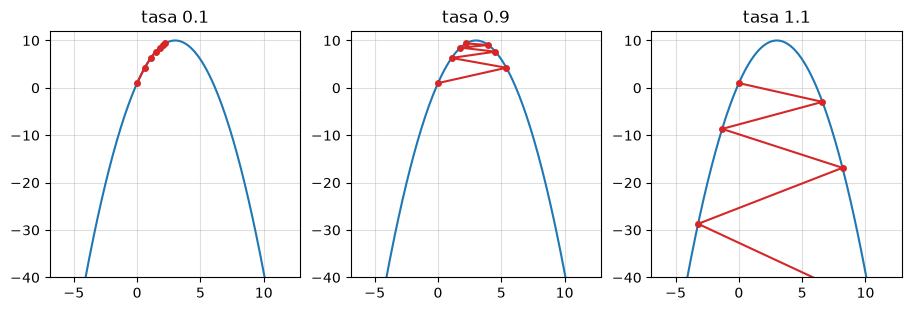

In [4]:
import matplotlib.pyplot as plt

xs = []
ys = []
for i in range(-60, 121):
    xs.append(i / 10)
    ys.append(colina(i / 10))

plt.figure(figsize=(11, 3.2))
for posicion, tasa in [(1, 0.1), (2, 0.9), (3, 1.1)]:
    camino = ascender(colina, 0.0, tasa, 6)
    alturas = []
    for x in camino:
        alturas.append(colina(x))
    plt.subplot(1, 3, posicion)
    plt.plot(xs, ys, color="tab:blue")
    plt.plot(camino, alturas, "o-", color="tab:red", markersize=4)
    plt.title("tasa " + str(tasa))
    plt.ylim(-40, 12)
    plt.grid(True, alpha=0.4)
plt.show()

Con **0,1**, los puntos suben ordenadamente hacia la cumbre. Con **0,9**, saltan de una ladera a la otra, pero cada vez más cerca. Con
**1,1**, cada salto los lleva **más abajo**: el algoritmo se ha vuelto loco.

Esta es la primera gran lección práctica del entrenamiento de redes neuronales, que te encontrarás **siempre**:

> **La tasa de aprendizaje es la ruedecilla más delicada de todas.** Muy pequeña: el aprendizaje es eterno. Muy grande: el aprendizaje
> oscila o **explota** (los números se disparan hacia infinito). Los profesionales pasan mucho tiempo ajustándola.

(A las ruedecillas como la tasa, que no son parte de la política sino del **método** de aprendizaje, se les llama **hiperparámetros**:
"los parámetros del que ajusta los parámetros".)


## 3 · El palo de escoba aprende su ruedecilla

Vamos a por un problema de verdad: la montaña del palo de escoba con batería del NB16. Primero, el mundo, ahora con **las dos**
ruedecillas como entradas (en el NB16 la de velocidad estaba fija en 8). Es el mismo código que en el NB16:


In [5]:
import random

def retorno(ruedecilla_inclinacion, ruedecilla_velocidad):
    total = 0
    for semilla in range(5):
        random.seed(semilla)
        inclinacion = 2.0
        velocidad = 0.0
        for n in range(500):
            empuje = -ruedecilla_inclinacion * inclinacion - ruedecilla_velocidad * velocidad
            if empuje > 40:
                empuje = 40
            if empuje < -40:
                empuje = -40
            aceleracion = 10 * inclinacion + empuje + random.uniform(-30, 30)
            velocidad = velocidad + aceleracion * 0.02
            inclinacion = inclinacion + velocidad * 0.02
            if inclinacion > 30 or inclinacion < -30:
                break
            total = total + 1 - (inclinacion / 30) ** 2 - 0.001 * empuje ** 2
    return total / 5

print("Retorno con (12, 8):", round(retorno(12, 8), 1))

Retorno con (12, 8): 420.6


Primero, **una sola ruedecilla**: dejamos la de velocidad en 8 y ajustamos la de inclinación, empezando en 12 (una política mediocre:
420,6 puntos). Para poder usar `pendiente`, que espera una función de **un** número, fabricamos una pequeña función que fija la velocidad
en 8:


In [6]:
def retorno_con_velocidad_8(r):
    return retorno(r, 8)

r = 12.0
tasa = 0.5
for paso in range(1, 9):
    p = pendiente(retorno_con_velocidad_8, r, 0.5)
    r = r + tasa * p
    print("paso", paso, "| pendiente", round(p, 2), "| ruedecilla", round(r, 2), "| retorno", round(retorno(r, 8), 2))

paso 1 | pendiente 27.53 | ruedecilla 25.77 | retorno 461.72
paso 2 | pendiente -0.22 | ruedecilla 25.65 | retorno 461.74
paso 3 | pendiente -0.21 | ruedecilla 25.55 | retorno 461.77
paso 4 | pendiente -0.2 | ruedecilla 25.45 | retorno 461.79
paso 5 | pendiente -0.19 | ruedecilla 25.35 | retorno 461.81
paso 6 | pendiente -0.19 | ruedecilla 25.26 | retorno 461.82
paso 7 | pendiente -0.18 | ruedecilla 25.17 | retorno 461.84
paso 8 | pendiente -0.17 | ruedecilla 25.08 | retorno 461.85


En el **primer paso**, la pendiente es enorme (+27,5: "¡sube mucho hacia la derecha!") y la ruedecilla salta de 12 a **25,8**. Desde
ahí, la pendiente es pequeña y negativa ("te has pasado un pelín"), y la ruedecilla va bajando despacito hacia la cumbre, que el NB16
encontró hacia 23-24. El retorno ha pasado de 420,6 a casi **462**: el máximo de la montaña.

Ha bastado con **unos pocos pasos**, y cada paso cuesta **2** evaluaciones (un poco a la izquierda y un poco a la derecha). En el NB16
necesitamos **53** evaluaciones para encontrar la cumbre recorriendo todos los valores.


## 4 · Dos ruedecillas: la pendiente se convierte en una flecha

Ahora, lo importante: **las dos ruedecillas a la vez**. Con dos ruedecillas, la "montaña" ya no es una línea: es una **superficie**, como
un terreno de verdad, con dos direcciones (la ruedecilla de inclinación y la de velocidad, como el x y el y del plano del NB12). En cada
punto, el terreno puede subir más en una dirección que en otra.

¿Cómo se mide la pendiente en un terreno así? Con una idea muy sencilla: **una dirección cada vez**.

1. Deja quieta la ruedecilla de velocidad, y mide la pendiente moviendo **solo** la de inclinación.
2. Deja quieta la de inclinación, y mide la pendiente moviendo **solo** la de velocidad.

A cada una de estas pendientes "por separado" se le llama **derivada parcial** ("parcial" porque solo mira una parte: una ruedecilla). Y
con las dos juntas se forma... ¡una **flecha** (NB12)! (pendiente en inclinación, pendiente en velocidad). Esa flecha se llama el
**gradiente**, y tiene una propiedad maravillosa:

> **El gradiente es una flecha que apunta hacia donde el terreno sube más deprisa.** Y su longitud dice cuánto de empinado es.

Así que la receta del ascenso es **la misma**, pero con flechas: posición nueva = posición + tasa × gradiente (suma de flechas y
multiplicación por un número, NB12).


In [7]:
def gradiente(funcion, a, b, h):
    # derivada parcial respecto a la primera ruedecilla (la segunda quieta)...
    parcial_a = (funcion(a + h, b) - funcion(a - h, b)) / (2 * h)
    # ...y respecto a la segunda (la primera quieta)
    parcial_b = (funcion(a, b + h) - funcion(a, b - h)) / (2 * h)
    return [parcial_a, parcial_b]

print("Gradiente en (12, 2):", [round(g, 2) for g in gradiente(retorno, 12, 2, 0.5)])

Gradiente en (12, 2): [26.87, 23.92]


En (12, 2), el gradiente es aproximadamente **(26,9; 23,9)**: el terreno sube mucho al aumentar **cualquiera** de las dos ruedecillas.
La flecha apunta "hacia arriba a la derecha" en el mapa. Vamos a seguirla: 30 pasos, tasa 0,5, empezando en (12, 2), y guardando el
camino para dibujarlo:


In [8]:
inclinacion_r = 12.0
velocidad_r = 2.0
tasa = 0.5
camino_a = [inclinacion_r]
camino_b = [velocidad_r]

print("inicio  | ruedecillas (12, 2) | retorno", round(retorno(12, 2), 2))
for paso in range(1, 31):
    g = gradiente(retorno, inclinacion_r, velocidad_r, 0.5)
    inclinacion_r = inclinacion_r + tasa * g[0]
    velocidad_r = velocidad_r + tasa * g[1]
    camino_a.append(inclinacion_r)
    camino_b.append(velocidad_r)
    if paso in [1, 2, 5, 10, 20, 30]:
        print("paso", paso, "| ruedecillas (", round(inclinacion_r, 2), ",", round(velocidad_r, 2), ") | retorno",
              round(retorno(inclinacion_r, velocidad_r), 2))

inicio  | ruedecillas (12, 2) | retorno 416.16
paso 1 | ruedecillas ( 25.44 , 13.96 ) | retorno 451.64
paso 2 | ruedecillas ( 25.62 , 12.84 ) | retorno 454.13
paso 5 | ruedecillas ( 25.9 , 9.98 ) | retorno 459.39
paso 10 | ruedecillas ( 25.56 , 7.41 ) | retorno 462.13


paso 20 | ruedecillas ( 23.9 , 6.56 ) | retorno 462.86


paso 30 | ruedecillas ( 22.55 , 6.21 ) | retorno 463.25


De **416** puntos a **463**, ajustando las dos ruedecillas a la vez, sin que nadie le diga dónde está la cumbre. El primer paso es un
salto grande hacia (25,4; 14), y luego el camino va corrigiendo poco a poco hacia unas ruedecillas en torno a (22,6; 6,2).

Para ver el camino de verdad, dibujemos el **mapa de la montaña**, como los mapas de senderismo que pintan las zonas altas de un color y
las bajas de otro. Calculamos el retorno en una cuadrícula de valores de las dos ruedecillas (con un bucle anidado, NB14) y lo pintamos
con `plt.contourf` (un "mapa de colores por alturas"; los detalles de la función no importan):


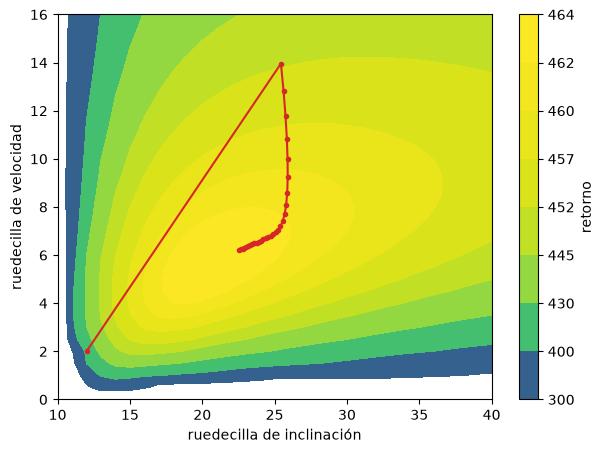

In [9]:
valores_a = []
for i in range(10, 41):
    valores_a.append(i)            # ruedecilla de inclinación: de 10 a 40
valores_b = []
for j in range(0, 33):
    valores_b.append(j / 2)        # ruedecilla de velocidad: de 0 a 16, de medio en medio

mapa = []
for b in valores_b:
    fila = []
    for a in valores_a:
        fila.append(retorno(a, b))
    mapa.append(fila)

plt.figure(figsize=(7, 5))
plt.contourf(valores_a, valores_b, mapa, levels=[300, 400, 430, 445, 452, 457, 460, 462, 464], cmap="viridis")
plt.colorbar(label="retorno")
plt.plot(camino_a, camino_b, "o-", color="tab:red", markersize=3)
plt.xlabel("ruedecilla de inclinación")
plt.ylabel("ruedecilla de velocidad")
plt.show()

Este es el **mapa de la montaña** visto desde arriba: los colores claros (amarillo) son las zonas altas, de mucho retorno; los oscuros
(morado), las bajas. Las zonas en blanco son donde el retorno es tan bajo que se sale de la escala (el palo se cae: ruedecilla de velocidad
muy pequeña). Y la línea roja es **el camino del aprendizaje**: empieza abajo a la izquierda, en (12, 2), da un gran salto hacia arriba y a
la derecha siguiendo el gradiente, y luego va bajando por la "cresta" amarilla hasta la zona más alta.

Esto es, literalmente, **lo que hace un algoritmo de entrenamiento**: caminar por un terreno invisible, siguiendo la flecha del gradiente,
hacia donde la recompensa es más alta. Con dos ruedecillas lo podemos dibujar; con 5.933, el terreno tiene 5.933 direcciones y no hay
dibujo posible... pero **la receta es idéntica**.


## 5 · La trampa: los óptimos locales

¿Recuerdas la **montaña con niebla** del NB04, con una colina cómoda (quedarse quieto) y la cumbre de verdad (andar) más lejos? El
ascenso por la pendiente **solo ve el terreno bajo sus pies**. Si empieza cerca de una colina pequeña, subirá a la colina pequeña... y ahí
se quedará, porque en su cima la pendiente es cero. No tiene forma de saber que hay una montaña más alta al otro lado del valle.

Comprobémoslo con un terreno de juguete con **dos colinas**: una pequeña (altura 3) cerca de x = 1, y una grande (altura 5) cerca de x = 6.
(La fórmula usa una función matemática que aún no hemos visto, la exponencial, para dibujar "campanas"; lo único que importa es su forma.)


Empezando en 0.0 -> termina en x = 1.0 con altura 3.0
Empezando en 4.0 -> termina en x = 6.0 con altura 5.0


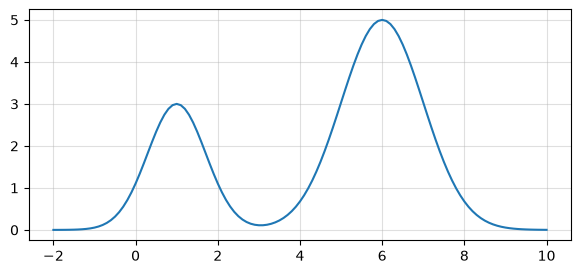

In [10]:
def dos_colinas(x):
    return 3 * 2.718281828 ** (-(x - 1) ** 2) + 5 * 2.718281828 ** (-(x - 6) ** 2 / 2)

for inicio in [0.0, 4.0]:
    camino = ascender(dos_colinas, inicio, 0.2, 200)
    final = camino[-1]
    print("Empezando en", inicio, "-> termina en x =", round(final, 2), "con altura", round(dos_colinas(final), 2))

xs = []
ys = []
for i in range(-20, 101):
    xs.append(i / 10)
    ys.append(dos_colinas(i / 10))
plt.figure(figsize=(7, 3))
plt.plot(xs, ys, color="tab:blue")
plt.grid(True, alpha=0.4)
plt.show()

- Empezando en **0**, el ascenso sube a la colina **pequeña** (x = 1, altura 3) y se queda ahí. Es un **óptimo local** (NB04): mejor que todo
  lo de alrededor, pero no lo mejor.
- Empezando en **4**, ya está en la ladera de la grande, y sube a la cumbre de verdad (x = 6, altura 5): el **óptimo global**.

**Dónde empiezas decide dónde acabas.** Esta es la gran limitación del ascenso por la pendiente, y la explicación de por qué el robot del
NB04 podía quedarse "quieto de pie" en vez de aprender a andar. Los profesionales tienen trucos para escapar (empezar desde varios sitios,
añadir algo de azar a los pasos —¡la exploración del NB03!—, diseñar la recompensa para que no haya colinas falsas...), y los irás
aprendiendo. Pero la trampa siempre está ahí.


## 6 · ¿Y para el humanoide? El problema del coste

Recapitulemos lo que cuesta cada paso del ascenso:

- Con **1** ruedecilla: 2 evaluaciones por paso (izquierda y derecha).
- Con **2** ruedecillas: 4 evaluaciones (2 por cada una).
- Con **N** ruedecillas: **2 × N** evaluaciones por paso.

Para la política lineal del humanoide (NB14-15), con **5.933** ruedecillas: unas **12.000** evaluaciones **por cada paso**, y cada
evaluación son 5 episodios en el simulador. Y harían falta cientos o miles de pasos. Es enormemente mejor que la búsqueda aleatoria (que no
llegaba **nunca**), pero sigue siendo **demasiado lento**.

Por eso los métodos de verdad hacen algo más listo. Hay dos ideas, que estudiaremos en las próximas lecciones:

1. **Calcular todas las pendientes de golpe.** Cuando la "montaña" es una fórmula que conocemos (como el error de una red neuronal al
   imitar ejemplos), existe un método, la **retropropagación**, que calcula las 5.933 pendientes **a la vez**, por el precio de unas pocas
   evaluaciones. Es lo que hace posible entrenar redes con millones de ruedecillas.
2. **Estimar la pendiente con los propios episodios.** En el aprendizaje por refuerzo, la montaña pasa por el simulador y no es una fórmula.
   Los algoritmos de verdad (con nombres como *policy gradient* o PPO, que llegarán) estiman hacia dónde girar las ruedecillas **observando
   qué acciones dieron buenos resultados** en los episodios, sin tener que mover cada ruedecilla por separado.

Pero el corazón de todo, en todos los casos, es lo que has hecho hoy: **seguir el gradiente**.


## 7 · Resumen de la lección

1. **Ascenso por la pendiente**: x nuevo = x + **tasa** × pendiente, y repetir. Sube solo hacia la cumbre, frenando al acercarse (el paso es
   proporcional a la pendiente). Bajando (x − tasa × pendiente) se llama **descenso por gradiente**.
2. La **tasa de aprendizaje** es un **hiperparámetro** delicado: muy pequeña, lentísimo; muy grande, **oscila** o **explota** (en la colina:
   0,01 lento, 0,1 bien, 0,9 oscila, 1,1 explota).
3. Con varias ruedecillas, se mide la pendiente de cada una por separado (**derivadas parciales**). Juntas forman el **gradiente**: una
   **flecha** que apunta hacia donde el terreno sube más deprisa.
4. El palo de escoba ajustó sus dos ruedecillas siguiendo el gradiente: de (12, 2) con 416 puntos a unos (22,6; 6,2) con ~463, en 30 pasos.
   Lo vimos en el **mapa de la montaña**.
5. Trampas: los **óptimos locales** (dónde empiezas decide dónde acabas) y el **coste** (2 evaluaciones por ruedecilla y paso). Para miles de
   ruedecillas hace falta calcular todas las pendientes a la vez (**retropropagación**) o estimarlas con los episodios (los métodos de RL).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Ascenso / descenso por gradiente** | Subir (o bajar) siguiendo la pendiente, paso a paso. |
| **Tasa de aprendizaje (*learning rate*)** | Lo largos que son los pasos del ascenso. |
| **Hiperparámetro** | Una ruedecilla del método de aprendizaje (no de la política), como la tasa. |
| **Oscilar / explotar** | Saltar de un lado a otro / alejarse cada vez más, por pasos demasiado largos. |
| **Derivada parcial** | La pendiente moviendo una sola ruedecilla, con las demás quietas. |
| **Gradiente** | La flecha de todas las derivadas parciales: apunta cuesta arriba. |
| **Óptimo local / global** | Una cima cualquiera / la cima más alta de todas. |
| **Retropropagación** | Método que calcula todas las pendientes de una red a la vez (llegará). |


## 8 · Ejercicios

**E1.** En la colina de juguete, si estás en x = 5 con tasa 0,1, ¿cuál es la pendiente (calcúlala con la regla del NB16: la pendiente de
−(x − 3)² es −2 × (x − 3)) y adónde te lleva el siguiente paso?

**E2.** Para **bajar** a un valle en vez de subir a una cumbre, ¿qué cambiarías en la receta? Pruébalo para encontrar el fondo de f(x) = x²
(NB16) empezando en x = 4, con tasa 0,1.

**E3.** Repite el ascenso del palo de escoba con dos ruedecillas pero con tasa **0,05**. ¿Llega igual de lejos en 30 pasos? ¿Y con tasa
**2**? (Cuidado: con tasas grandes, las ruedecillas pueden irse a valores absurdos.)

**E4.** En las dos colinas, ¿desde qué puntos de inicio crees que se acaba en la colina grande? Prueba con 2, 3 y 3,5.

**E5.** ¿Cuántas evaluaciones del retorno hace falta para **un** paso del ascenso con una política de 100 ruedecillas? ¿Y para 100 pasos?

**E6.** **Reto.** Empieza el ascenso del palo de escoba desde (40, 15) (ruedecillas grandes, que derrochan batería). ¿Adónde llega? ¿Es la
misma cumbre que desde (12, 2)?


<details>
<summary>▶ Solución E1</summary>

Pendiente en x = 5: −2 × (5 − 3) = **−4** (sube hacia la izquierda: la cumbre está en 3). Siguiente paso: 5 + 0,1 × (−4) = **4,6**. Se
acerca a 3, desde la derecha.
</details>

<details>
<summary>▶ Solución E2</summary>

Se **resta** en vez de sumar: x nuevo = x − tasa × pendiente (ir **en contra** de la pendiente es ir cuesta abajo).

```python
def f(x):
    return x ** 2

x = 4.0
for paso in range(20):
    x = x - 0.1 * pendiente(f, x, 0.001)
print(round(x, 4))
```

Sale aproximadamente **0,046**, acercándose a 0, el fondo de la U. Esto es el **descenso por gradiente**, el que se usa para hacer un
**error** lo más pequeño posible (lo veremos en el NB18).
</details>

<details>
<summary>▶ Solución E3</summary>

Copia el bucle del apartado 4 cambiando `tasa = 0.5` por `tasa = 0.05`. Con 0,05 los pasos son diez veces más cortos y el camino es
**distinto**: tras 30 pasos acaba en torno a (17,1; 4,6) con unos **461,9** puntos. Casi tan alto, pero llegando más despacio y por otro lado de la
cima (si siguiera más pasos, se acercaría aún más). Con tasa **2**, el primer paso es gigantesco (el gradiente inicial ronda 27 y 24, así que salta
unas 50 unidades en cada ruedecilla) y aterriza lejos; tras 30 pasos sigue en torno a (43,5; 10,2) con unos **453,7** puntos, lejos de la cumbre.
Es la lección de la colina de juguete: las tasas demasiado grandes dan saltos sin control.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
for inicio in [2.0, 3.0, 3.5]:
    print(inicio, round(ascender(dos_colinas, inicio, 0.2, 200)[-1], 2))
```

Empezando en **2** y en **3**, se acaba en la colina **pequeña** (x = 1); empezando en **3,5**, en la **grande** (x = 6). El valle entre las
dos colinas está, por tanto, entre 3 y 3,5: si empiezas a su izquierda, la pendiente te lleva a la colina pequeña; si empiezas a su derecha, a la
grande. Cada punto de inicio "pertenece" a una de las dos colinas, como el agua de lluvia, que según en qué lado de una montaña caiga, acaba en un
río o en otro.
</details>

<details>
<summary>▶ Solución E5</summary>

Con 100 ruedecillas: **2 × 100 = 200** evaluaciones por paso (y cada evaluación, en el palo de escoba, son 5 episodios: 1.000 episodios por
paso). Para 100 pasos: **20.000** evaluaciones (100.000 episodios). Con la política del humanoide (5.933 ruedecillas) serían casi 12.000
evaluaciones por paso. Por eso hace falta la retropropagación o los métodos de RL.
</details>

<details>
<summary>▶ Solución E6</summary>

Cambia el inicio a `inclinacion_r = 40.0` y `velocidad_r = 15.0`. El gradiente apunta hacia ruedecillas **más pequeñas** (la montaña baja al
derrochar batería), y el camino va hacia la misma zona alta de antes. Pero tras 30 pasos todavía está en torno a (33,7; 8,6), con unos **458**
puntos: por ese lado, la ladera es muy **suave** (pendientes pequeñas), así que los pasos son cortos y se avanza despacio. Con más pasos seguiría
acercándose a la misma cumbre (~463). En esta montaña solo hay **una** zona alta, así que no hay óptimos locales que molesten; lo que sí se ve es
que **las laderas suaves se suben despacio**. (El humanoide no tendrá tanta suerte con los óptimos locales.)
</details>


## 9 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has escrito el algoritmo más importante de la inteligencia artificial: **seguir el gradiente**. Has visto que una flecha de pendientes
lleva al palo de escoba hasta su mejor política, has aprendido a temer a la tasa de aprendizaje, y has visto por qué un robot puede quedarse
atascado en una colina falsa.

En el **NB18** usaremos el descenso por gradiente para una forma de aprender **distinta y muy potente**: aprender **imitando**. Le enseñaremos
a una neurona **ejemplos** de lo que hace la política buena del palo de escoba ("en esta situación, empujó tanto"), y la neurona, bajando por
la pendiente de su **error**, **redescubrirá sola** los números −30 y −8. Es el **aprendizaje supervisado**, y con él veremos por primera vez
cómo se calculan las pendientes de golpe, sin tener que mover cada ruedecilla por separado.
